In [ ]:
# Este cuaderno está basado en
# ai-page.readthedocs.io

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Tenga en cuenta

F-test es la significancia del modelo y plantea que
$$ H_{0}: \beta_{1}  = ... = \beta_{n} = 0$$
y  la alternativa es que alemnos una es diferente de cero.

# Evaluación del modelo

$$ RMSE = \frac{SSE}{n-k-1}$$


$$AdjR^{2} = 1 - \frac{(1-R^{2})(n-1)}{n-k-1}$$

donde $k$ es el número de predictores usados en la regresión y $n$ el número de datos.

In [ ]:
# import all stock market data into DataFrame
root = "https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/"
aord = pd.read_csv(root + 'ALLOrdinary.csv')
nikkei = pd.read_csv(root + '/Nikkei225.csv')
hsi = pd.read_csv(root + 'HSI.csv')
daxi = pd.read_csv(root + 'DAXI.csv')
cac40 = pd.read_csv(root + 'CAC40.csv')
sp500 = pd.read_csv(root + 'SP500.csv')
dji = pd.read_csv(root + 'DJI.csv')
nasdaq = pd.read_csv(root + 'nasdaq_composite.csv')
spy = pd.read_csv(root + 'SPY.csv')

In [ ]:
# Due to the timezone issues, we extract and calculate appropriate stock market data for analysis
# Indicepanel is the DataFrame of our trading model
indicepanel=pd.DataFrame(index=spy.index)

indicepanel['spy']=spy['Open'].shift(-1)-spy['Open']
indicepanel['spy_lag1']=indicepanel['spy'].shift(1)
indicepanel['sp500']=sp500["Open"]-sp500['Open'].shift(1)
indicepanel['nasdaq']=nasdaq['Open']-nasdaq['Open'].shift(1)
indicepanel['dji']=dji['Open']-dji['Open'].shift(1)

indicepanel['cac40']=cac40['Open']-cac40['Open'].shift(1)
indicepanel['daxi']=daxi['Open']-daxi['Open'].shift(1)

indicepanel['aord']=aord['Close']-aord['Open']
indicepanel['hsi']=hsi['Close']-hsi['Open']
indicepanel['nikkei']=nikkei['Close']-nikkei['Open']
indicepanel['Price']=spy['Open']

In [ ]:
# We can use method 'fillna()' from dataframe to forward filling the Nan values
# Then we can drop the reminding Nan values
indicepanel = indicepanel.fillna(method='ffill')
indicepanel = indicepanel.dropna()

<ipython-input-76-ca796bc00fd3>:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  indicepanel = indicepanel.fillna(method='ffill')


In [ ]:
#split the data into (1)train set and (2)test set

Train = indicepanel.iloc[-2000:-1000, :]
Test = indicepanel.iloc[-1000:, :]
print(Train.shape, Test.shape)

(1000, 11) (1000, 11)


In [ ]:
formula = 'spy~spy_lag1+sp500+nasdaq+dji+cac40+aord+daxi+nikkei+hsi'
lm = smf.ols(formula=formula, data=Train).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    spy   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     2.133
Date:                Wed, 14 May 2025   Prob (F-statistic):             0.0245
Time:                        01:46:22   Log-Likelihood:                -1643.1
No. Observations:                1000   AIC:                             3306.
Df Residuals:                     990   BIC:                             3355.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0798      0.040      1.993      0.0

In [ ]:
Train['PredictedY'] = lm.predict(Train)
Test['PredictedY'] = lm.predict(Test)

<ipython-input-79-0bd8b27bf604>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Train['PredictedY'] = lm.predict(Train)
<ipython-input-79-0bd8b27bf604>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Test['PredictedY'] = lm.predict(Test)


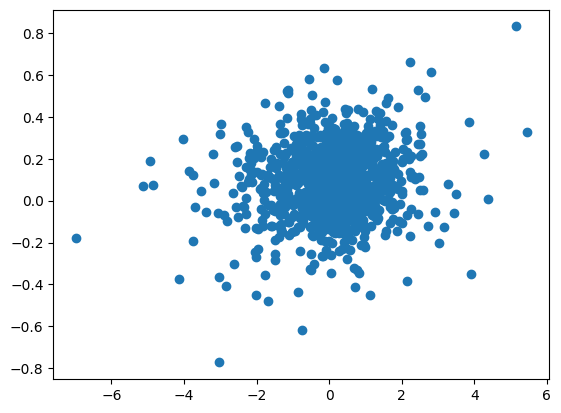

In [ ]:
plt.scatter(Train['spy'], Train['PredictedY'])

In [ ]:
from statsmodels.tools.eval_measures import rmse

print("en entrenamiento", rmse(Train['spy'], Train['PredictedY']))
print("en entrenamiento", rmse(Test['spy'], Test['PredictedY']))

en entrenamiento 1.2512302148249541
en entrenamiento 1.7508727989633162


In [ ]:
# check assumptions??